In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [2]:
def make_sample_data(n_days: int = 120, seed: int = 7) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    start = datetime.today() - timedelta(days=n_days)
    dates = [start + timedelta(days=i) for i in range(n_days)]
    categories = rng.choice(
        ["Alpha", "Beta", "Gamma"], size=n_days, p=[0.4, 0.35, 0.25]
    )
    baseline = np.linspace(10, 40, n_days)
    seasonal = 6 * np.sin(np.linspace(0, 4 * np.pi, n_days))
    noise = rng.normal(0, 3, n_days)
    cat_offset = {"Alpha": 0, "Beta": 5, "Gamma": -4}
    values = baseline + seasonal + noise + np.vectorize(cat_offset.get)(categories)
    df = pd.DataFrame(
        {
            "date": pd.to_datetime(dates),
            "category": categories,
            "value": values,
        }
    )
    return df

In [ ]:
def make_plot(df: pd.DataFrame, out_path: str = "sample_plot.png"):
    sns.set_theme(style="whitegrid", context="talk", palette="viridis")
    plt.figure(figsize=(15, 10))
    # Line plot per category (rolling mean for smoothing)
    for cat, sub in df.groupby("category"):
        sub_sorted = sub.sort_values("date")
        smooth = sub_sorted.assign(
            smooth=sub_sorted["value"]
            .rolling(window=7, min_periods=1, center=True)
            .mean()
        )
        plt.plot(
            smooth["date"],
            smooth["smooth"],
            label=f"{cat} (7‑day smooth)",
            linewidth=2.2,
            alpha=0.9,
        )
        plt.scatter(
            sub_sorted["date"],
            sub_sorted["value"],
            s=18,
            alpha=0.35,
            edgecolor="none",
        )

    plt.title("Sample time series by category")
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend(frameon=True, title="Series")
    plt.tight_layout()
    plt.show()

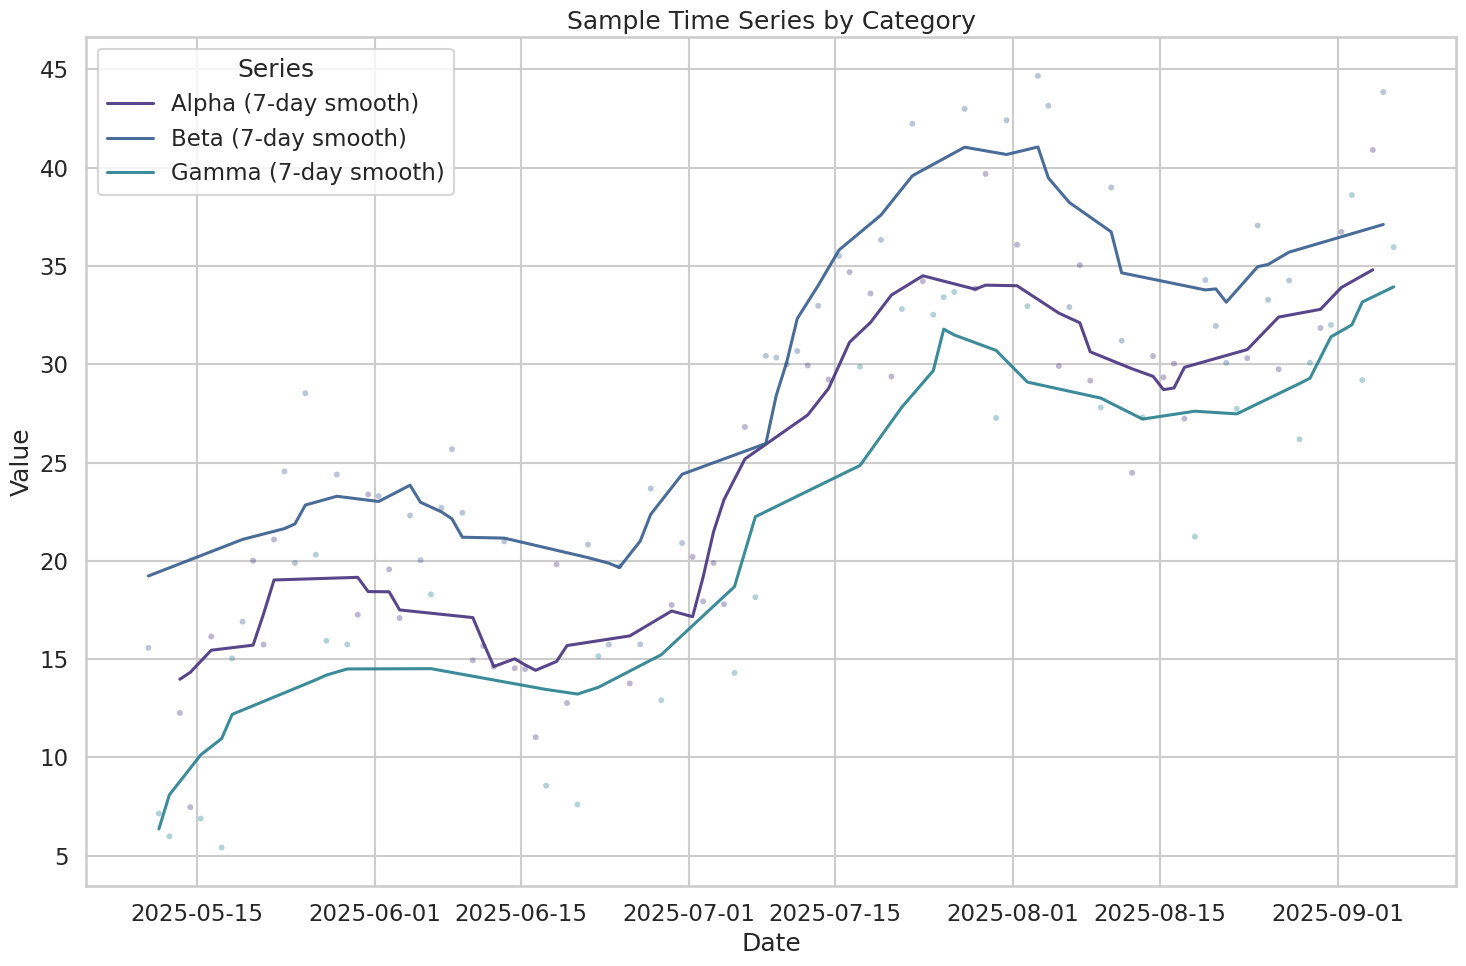

None


Bad pipe message: %s [b'0.9,*/*;q=0.8\r\nHost: localhost:41961\r\nUser-Agent: Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/60', b'1.15 (KHTML, like Gecko) Version/18.3 Safari/605.1.1']
Bad pipe message: %s [b'\nAccept-Encoding: gzip, deflate, br\r\nAccept-Language', b'en-GB,en;q=0.9\r\nReferer: https://probable-sniffle-x956wvp']
Bad pipe message: %s [b'jqf67jq.github.dev/\r\nX-Request-ID: 56abfd73159b894844']
Bad pipe message: %s [b'0c9b7278aada\r\nX-Real-IP: 90.250.181.54\r\nX-Forwarded-Por', b' 443\r\nX-Forwarded-Scheme: https\r\nX-Original-URI: /\r\nX-Scheme: https\r\nsec-fetch-site: same-site\r\npriority: u=0, i\r\ns']
Bad pipe message: %s [b' Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/18.3 Safari/605.1']
Bad pipe message: %s [b'5\r\nAccept-Encoding: gzip, deflate, br\r\nAccept', b'anguage: en-GB,en;q=0.9\r\nReferer: https://pr']
Bad pipe message: %s [b'able-sniffle-x956wvp6vjqf67jq-41961.app.github.dev/\r\nX-Requ

In [4]:
df = make_sample_data()
print(make_plot(df))